**LAB-2**

GROUP NUMBER: 3

GROUP MEMBER: A.HEMANT KUMAAR, JACK LICHWA , PRITHIKA K


**PIT STOP ANALYSIS PROJECT**

**PROJECT BACKGROUND**

Formula 1 (F1) is the pinnacle of motorsport, combining elite driver skill with cutting-edge engineering. A critical and often race-deciding element of F1 strategy is the **pit stop**  a brief pause in which a team changes tires, makes aerodynamic adjustments, or responds to race incidents. The duration of a pit stop, even down to fractions of a second, can determine whether a driver retains or loses a podium position.

For top-finishing drivers (those who finish in the top 3), pit stop strategy is especially high-stakes. A slow stop can cost a driver a podium; an efficiently timed stop can vault them ahead of a competitor. Understanding what factors influence the **maximum pit stop duration** experienced by top 3 finishers has implications for race engineering, team strategy optimization, and performance analytics.

This study investigates whether historical race data, tire information, and race conditions can be used to predict the maximum pit stop duration among the top three drivers in a Formula 1 race. Can the maximum pit stop duration for the top 3 drivers in a Formula 1 race be predicted using race context and historical performance data?

**DATASET & DESCRIPTION**

**Source**: All datasets come from Kaggle: “Formula 1 Race Data” by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

**Key Variable**:
At this stage, we are exploring all variables from the pit stops, races, circuits, drivers, constructors, lap times, qualifying, and results datasets. Final selection of key predictor variables will be based on further analysis and exploratory data analysis (EDA), including correlations, distributions, and relevance to pit stop duration.

**Data Type**: The datasets include a mix of numeric, categorical, ordinal, and datetime variables:

- Numeric: milliseconds, lap, round, year, alt, points, positionOrder
- Categorical: driverId, surname, constructorId, constructor name, circuitId, location, country, status
- Ordinal: stop (pit stop sequence), grid position, and finishing positions
- Datetime: race dates (races.date) and driver birth dates (drivers.dob)

These variables provide the foundation for preprocessing and exploratory analysis to identify potential predictors for pit stop duration.



| File | Description |
|---|---|
| `pit_stops.csv` | Per-stop timing data for every driver in every race (2011+) |
| `results.csv` | Final race outcomes: grid, finish position, points, laps, fastest lap |
| `races.csv` | Race metadata: year, round, circuit, date |
| `circuits.csv` | Circuit details: name, location, country, altitude |
| `drivers.csv` | Driver info: name, nationality, date of birth |
| `constructors.csv` | Constructor (team) name and nationality |
| `lap_times.csv` | Per-lap timing for every driver (used to derive race pace features) |
| `qualifying.csv` | Q1/Q2/Q3 qualifying times per driver per race |
| `driver_standings.csv` | Cumulative championship standings after each race |
| `constructor_standings.csv` | Cumulative constructor championship standings |
| `status.csv` | Lookup: race exit status (Finished, Engine, Accident, etc.) |


**SETUP AND DATA LOADING**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

print('Libraries loaded.')

Libraries loaded.


In [ ]:
import kagglehub

# Download latest version using kagglehub
path = kagglehub.dataset_download("jtrotman/formula-1-race-data")

DATA_PATH = path + '/' # Set DATA_PATH to the downloaded directory

pit_stops            = pd.read_csv(DATA_PATH + 'pit_stops.csv')
results              = pd.read_csv(DATA_PATH + 'results.csv')
races                = pd.read_csv(DATA_PATH + 'races.csv')
circuits             = pd.read_csv(DATA_PATH + 'circuits.csv')
drivers              = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors         = pd.read_csv(DATA_PATH + 'constructors.csv')
lap_times            = pd.read_csv(DATA_PATH + 'lap_times.csv')
qualifying           = pd.read_csv(DATA_PATH + 'qualifying.csv')
driver_standings     = pd.read_csv(DATA_PATH + 'driver_standings.csv')
constructor_standings= pd.read_csv(DATA_PATH + 'constructor_standings.csv')
status               = pd.read_csv(DATA_PATH + 'status.csv')

print('All files loaded.')

all_dfs = {
    'pit_stops': pit_stops, 'results': results, 'races': races,
    'circuits': circuits, 'drivers': drivers, 'constructors': constructors,
    'lap_times': lap_times, 'qualifying': qualifying,
    'driver_standings': driver_standings, 'status': status
}
print(f"\n{'File':<28} {'Rows':>10} {'Cols':>6}")
print('-' * 46)
for name, df in all_dfs.items():
    print(f'{name:<28} {df.shape[0]:>10,} {df.shape[1]:>6}')

100%|██████████| 6.64M/6.64M [00:01<00:00, 4.41MB/s]

Extracting files...


All files loaded.

File                               Rows   Cols
----------------------------------------------
pit_stops                        22,193      7
results                          27,304     18
races                             1,171     18
circuits                             78      9
drivers                             865      9
constructors                        214      5
lap_times                       618,766      6
qualifying                       11,036      9
driver_standings                 35,427      7
status                              140      2


### Data Cleaning: Convert `duration` and `milliseconds` to Numeric Types

From the `.info()` and `.describe()` outputs, we noticed that `duration` and `milliseconds` columns are currently of `object` (string) type. To perform numerical calculations, we need to convert them to appropriate numeric types. We'll convert `duration` to a float and `milliseconds` to an integer.

In [ ]:
# Merge pit_stops with races to get race year and circuit information
pit_stops_merged = pit_stops.merge(races[['raceId', 'year', 'name', 'circuitId']], on='raceId', how='left')

# Merge with results to get driver position, constructorId, and statusId
pit_stops_merged = pit_stops_merged.merge(results[['raceId', 'driverId', 'constructorId', 'positionOrder', 'statusId']], on=['raceId', 'driverId'], how='left')

# Merge with drivers to get driver name
pit_stops_merged = pit_stops_merged.merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')

# Merge with constructors to get constructor name
pit_stops_merged = pit_stops_merged.merge(constructors[['constructorId', 'name']], on='constructorId', how='left', suffixes=('_driver', '_constructor'))

# Rename columns for clarity
pit_stops_merged = pit_stops_merged.rename(columns={'name_driver': 'race_name', 'name_constructor': 'constructor_name'})

print("Merged pit_stops_merged DataFrame head:")
print(pit_stops_merged.head())
print(f"\nShape of merged DataFrame: {pit_stops_merged.shape}")

Merged pit_stops_merged DataFrame head:
   raceId  driverId  stop  lap      time duration milliseconds  year  \
0     258       100     1    1  14:01:34   49.111        49111  1994   
1     258        79     1   17  14:20:46   28.482        28482  1994   
2     258        57     1   18  14:22:35   43.745        43745  1994   
3     258        71     1   18  14:23:00   21.992        21992  1994   
4     258       105     1   19  14:24:39   27.693        27693  1994   

            race_name  circuitId  constructorId  positionOrder  statusId  \
0  Pacific Grand Prix         28             33              6        13   
1  Pacific Grand Prix         28             25             20         5   
2  Pacific Grand Prix         28              1             21         6   
3  Pacific Grand Prix         28              3             18         7   
4  Pacific Grand Prix         28             18             14         4   

  forename   surname constructor_name  
0     Érik     Comas        La

In [ ]:
# Filter for pit stops of top 3 finishers
pit_stops_top3 = pit_stops_merged[pit_stops_merged['positionOrder'].isin([1, 2, 3])]

print("Filtered pit_stops_top3 DataFrame head:")
print(pit_stops_top3.head())
print(f"\nShape of filtered DataFrame: {pit_stops_top3.shape}")

Filtered pit_stops_top3 DataFrame head:
    raceId  driverId  stop  lap      time duration milliseconds  year  \
8      258        30     1   23  14:28:40   23.342        23342  1994   
14     258        77     1   27  14:34:28   24.334        24334  1994   
19     258        22     1   31  14:39:42    26.15        26150  1994   
28     258        30     2   51  15:04:18   24.181        24181  1994   
33     258        77     2   57  15:11:53   23.066        23066  1994   

             race_name  circuitId  constructorId  positionOrder  statusId  \
8   Pacific Grand Prix         28             22              1         1   
14  Pacific Grand Prix         28              6              2         1   
19  Pacific Grand Prix         28             17              3        11   
28  Pacific Grand Prix         28             22              1         1   
33  Pacific Grand Prix         28              6              2         1   

   forename      surname constructor_name  
8   Michael   

In [ ]:
# Convert 'duration' to numeric (float)
pit_stops_top3['duration'] = pd.to_numeric(pit_stops_top3['duration'], errors='coerce')

# Convert 'milliseconds' to numeric (int)
pit_stops_top3['milliseconds'] = pd.to_numeric(pit_stops_top3['milliseconds'], errors='coerce')

# Check the data types after conversion
print("Data types after conversion:")
pit_stops_top3[['duration', 'milliseconds']].info()

# Display descriptive statistics for the converted columns to confirm
print("\nDescriptive statistics for 'duration' and 'milliseconds' after conversion:")
print(pit_stops_top3[['duration', 'milliseconds']].describe())

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 3461 entries, 8 to 22177
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   duration      3372 non-null   float64
 1   milliseconds  3461 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 81.1 KB

Descriptive statistics for 'duration' and 'milliseconds' after conversion:
          duration  milliseconds
count  3372.000000  3.461000e+03
mean     25.410241  6.067670e+04
std       4.735497  2.385094e+05
min      10.164000  1.016400e+04
25%      22.121500  2.218400e+04
50%      24.349000  2.447300e+04
75%      28.317500  2.865300e+04
max      53.521000  3.046888e+06


In [ ]:
# Display basic information and descriptive statistics for pit_stops_top3
print("pit_stops_top3 DataFrame Info:")
pit_stops_top3.info()

print("\npit_stops_top3 Descriptive Statistics:")
print(pit_stops_top3.describe(include='all'))


pit_stops_top3 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3461 entries, 8 to 22177
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   raceId            3461 non-null   int64  
 1   driverId          3461 non-null   int64  
 2   stop              3461 non-null   int64  
 3   lap               3461 non-null   int64  
 4   time              3461 non-null   object 
 5   duration          3372 non-null   float64
 6   milliseconds      3461 non-null   int64  
 7   year              3461 non-null   int64  
 8   race_name         3461 non-null   object 
 9   circuitId         3461 non-null   int64  
 10  constructorId     3461 non-null   int64  
 11  positionOrder     3461 non-null   int64  
 12  statusId          3461 non-null   int64  
 13  forename          3461 non-null   object 
 14  surname           3461 non-null   object 
 15  constructor_name  3461 non-null   object 
dtypes: float64(1), 


**Key Variable Definitions & Data Types**

The dataset contains a mix of numeric, categorical, ordinal, and datetime variables across files.

##### `pit_stops.csv` — Primary File
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `raceId` | Integer — **Nominal** | Join key | Links to `races.csv` |
| `driverId` | Integer — **Nominal** | Join key | Links to `drivers.csv` |
| `stop` | Integer — **Ordinal** | Predictor | Pit stop sequence number (1st, 2nd, 3rd…) |
| `lap` | Integer — **Discrete** | Predictor | Lap on which the pit stop occurred |
| `time` | String (HH:MM:SS) | Context | Clock time of pit stop |
| `duration` | Float — **Continuous** | Feature / Target-component | Pit stop duration in seconds |
| `milliseconds` | Integer — **Continuous** | Feature / Target-component | Duration in milliseconds |

##### `results.csv` — Race Outcomes
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `grid` | Integer — **Ordinal** | Predictor | Starting grid position |
| `positionOrder` | Integer — **Ordinal** | Filter / Predictor | Final finishing position |
| `points` | Float — **Continuous** | Predictor | Championship points earned |
| `laps` | Integer — **Discrete** | Predictor | Total laps completed |
| `fastestLapSpeed` | Float — **Continuous** | Predictor | Speed (km/h) of driver's fastest lap |
| `statusId` | Integer — **Nominal** | Filter | Links to `status.csv` |
| `constructorId` | Integer — **Nominal** | Join key | Links to `constructors.csv` |

##### `races.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `year` | Integer — **Ordinal** | Predictor | Season year |
| `round` | Integer — **Ordinal** | Predictor | Race round within the season |
| `circuitId` | Integer — **Nominal** | Join key | Links to `circuits.csv` |
| `date` | String → **Datetime** | Feature | Date of the race |

##### `circuits.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `name` | String — **Categorical** | Predictor | Circuit name |
| `country` | String — **Categorical** | Predictor | Host country |
| `location` | String — **Categorical** | Context | City/region |
| `alt` | Integer — **Continuous** | Predictor | Circuit altitude (meters) — affects engine/tire behavior |
| `lat` / `lng` | Float — **Continuous** | Context | Geographic coordinates |

##### `drivers.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `surname` | String — **Categorical** | Context | Driver last name |
| `nationality` | String — **Categorical** | Predictor | Driver nationality |
| `dob` | String → **Datetime** | Feature-eng | Date of birth (used to compute driver age at race) |

##### `qualifying.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `position` | Integer — **Ordinal** | Predictor | Final qualifying position |
| `q1`, `q2`, `q3` | String → Float — **Continuous** | Predictor | Qualifying lap times per session |


In [ ]:
# Inspect primary tables
print('=== pit_stops.csv — first rows ===')
display(pit_stops.head(8))
print('\nData types:')
print(pit_stops.dtypes)

=== pit_stops.csv — first rows ===


,raceId,driverId,stop,lap,time,duration,milliseconds
0,258,100,1,1,14:01:34,49.111,49111
1,258,79,1,17,14:20:46,28.482,28482
2,258,57,1,18,14:22:35,43.745,43745
3,258,71,1,18,14:23:00,21.992,21992
4,258,105,1,19,14:24:39,27.693,27693
5,258,91,1,19,14:24:41,24.806,24806
6,258,44,1,18,14:25:13,53.89,53890
7,258,94,1,22,14:28:34,34.437,34437



Data types:
raceId           int64
driverId         int64
stop             int64
lap              int64
time            object
duration        object
milliseconds    object
dtype: object


In [ ]:
print('=== results.csv — first rows ===')
display(results.head(5))
print('\nData types:')
print(results.dtypes)

=== results.csv — first rows ===


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1



Data types:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                object
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object


**HANDLING MISSING VALUES**

In [ ]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({'Missing': miss, 'Pct (%)': pct})
    out  = out[out['Missing'] > 0]
    if out.empty:
        print(f'{name:<30} No missing values')
    else:
        print(f'\n── {name} ──')
        display(out)

for name, df in all_dfs.items():
    missing_report(df, name)

pit_stops                      No missing values
results                        No missing values
races                          No missing values
circuits                       No missing values
drivers                        No missing values
constructors                   No missing values
lap_times                      No missing values
qualifying                     No missing values
driver_standings               No missing values
status                         No missing values


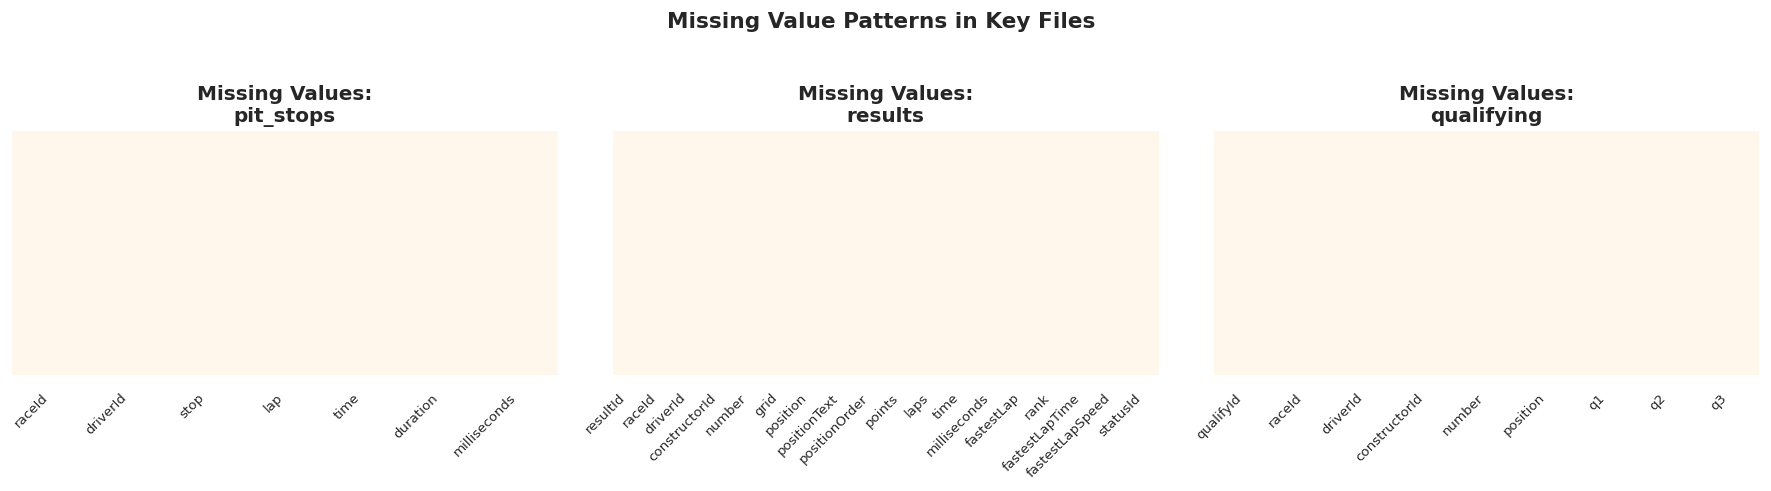

In [ ]:
# Visual: missing value heatmap for the three most important files
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('pit_stops', pit_stops),
                                   ('results',   results),
                                   ('qualifying', qualifying)]):
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
                ax=ax, cmap='OrRd')
    ax.set_title(f'Missing Values:\n{name}', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.suptitle('Missing Value Patterns in Key Files', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


| File | Missing Pattern | Handling Strategy |
|---|---|---|
| `pit_stops.csv` | Typically none — clean file | No action needed |
| `results.csv` | `fastestLapTime`, `fastestLapSpeed`, `fastestLap` missing for pre-2004 races | Drop rows or subset to 2011+ (when pit stops begin) |
| `qualifying.csv` | `q2` missing for Q1-eliminees; `q3` missing for Q2-eliminees | **Structural missingness** — use best available time (`q1_sec`, etc.) |
| `circuits.csv` | Some `alt` values may be `\\N` (null string) | Parse and impute with median altitude |
| `drivers.csv` | `dob` occasionally missing | Drop or skip age feature for those rows |


**Key note: Pit stop data only exists from 2011 onwards. All modeling will be restricted to this period.**

**DATA PREPROCESSING**

In [ ]:
# ── Parse dates ─────────────────────────────────────────────────
races['date']   = pd.to_datetime(races['date'], errors='coerce')
races['year']   = races['date'].dt.year
drivers['dob']  = pd.to_datetime(drivers['dob'], errors='coerce')

# ── Clean pit stop duration ─────────────────────────────────────
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors='coerce')
# Remove implausible durations (< 1.5s is physically impossible; > 300s = likely red flag)
pit_clean = pit_stops[(pit_stops['duration'] >= 1.5) &
                       (pit_stops['duration'] <= 300)].copy()
print(f'pit_stops raw: {len(pit_stops):,} rows → after cleaning: {len(pit_clean):,} rows')

# ──Clean altitude in circuits ──────────────────────────────────
circuits['alt'] = pd.to_numeric(circuits['alt'], errors='coerce')
circuits['alt'].fillna(circuits['alt'].median(), inplace=True)

# ── Identify top-3 finishers per race ───────────────────────────
top3_results = results[results['positionOrder'].isin([1, 2, 3])].copy()
top3_results = top3_results.merge(
    races[['raceId', 'year', 'round', 'circuitId', 'name']],
    on='raceId', how='left'
).rename(columns={'name': 'race_name'})
# Restrict to 2011+ (pit stop data availability)
top3_results = top3_results[top3_results['year'] >= 2011]
print(f'Top-3 finisher records (2011+): {len(top3_results):,}')

# ──Merge top-3 with pit stops ──────────────────────────────────
top3_pits = top3_results.merge(
    pit_clean[['raceId', 'driverId', 'stop', 'lap', 'duration', 'milliseconds']],
    on=['raceId', 'driverId'], how='inner'
)
print(f'Top-3 pit stop records: {len(top3_pits):,}')

# ── Build the TARGET variable: max pit stop duration per race for top-3 ─ Group by race → among all top-3 drivers' pit stops, find the maximum duration
target_df = (
    top3_pits.groupby('raceId')
    .agg(
        max_pit_duration   = ('duration', 'max'),
        mean_pit_duration  = ('duration', 'mean'),
        min_pit_duration   = ('duration', 'min'),
        total_pit_stops    = ('stop', 'count'),
    )
    .reset_index()
)

# Merge race-level metadata
target_df = target_df.merge(
    races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']],
    on='raceId', how='left'
).rename(columns={'name': 'race_name'})

# Merge circuit info
target_df = target_df.merge(
    circuits[['circuitId', 'name', 'country', 'alt', 'lat', 'lng']],
    on='circuitId', how='left'
).rename(columns={'name': 'circuit_name'})

print(f'Final target dataset shape: {target_df.shape}')
display(target_df.head(8))

# ── Parse qualifying times ──────────────────────────────────────
def parse_time(t):
    try:
        parts = str(t).split(':')
        return int(parts[0]) * 60 + float(parts[1])
    except:
        return np.nan

for col in ['q1', 'q2', 'q3']:
    qualifying[f'{col}_sec'] = qualifying[col].apply(parse_time)
qualifying['best_qual_sec'] = qualifying[['q1_sec', 'q2_sec', 'q3_sec']].min(axis=1)

# ── Driver age at race ───────────────────────────────────────────
drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
race_dates = races[['raceId', 'date', 'year']]
results_aug = results.merge(race_dates, on='raceId', how='left')
results_aug = results_aug.merge(drivers[['driverId', 'driver_name', 'nationality', 'dob']], on='driverId', how='left')
results_aug['driver_age'] = ((results_aug['date'] - results_aug['dob']).dt.days / 365.25).round(1)

print('Qualifying times and driver ages computed.')

pit_stops raw: 22,193 rows → after cleaning: 21,452 rows
Top-3 finisher records (2011+): 939
Top-3 pit stop records: 1,728
Final target dataset shape: (309, 15)


,raceId,max_pit_duration,mean_pit_duration,min_pit_duration,total_pit_stops,year,round,circuitId,race_name,date,circuit_name,country,alt,lat,lng
0,841,25.683,23.880500,22.603,6,2011,1,1,Australian Grand Prix,2011-03-27,Albert Park Grand Prix Circuit,Australia,10,-37.84970,144.968000
1,842,23.900,22.700222,21.893,9,2011,2,2,Malaysian Grand Prix,2011-04-10,Sepang International Circuit,Malaysia,18,2.76083,101.738000
2,843,23.442,21.396375,20.533,8,2011,3,17,Chinese Grand Prix,2011-04-17,Shanghai International Circuit,China,5,31.33890,121.220000
3,844,22.087,21.010917,20.112,12,2011,4,5,Turkish Grand Prix,2011-05-08,Istanbul Park,Turkey,130,40.95170,29.405000
4,845,20.988,20.290909,19.761,11,2011,5,4,Spanish Grand Prix,2011-05-22,Circuit de Barcelona-Catalunya,Spain,109,41.57000,2.261110
5,846,31.382,26.940167,24.670,6,2011,6,6,Monaco Grand Prix,2011-05-29,Circuit de Monaco,Monaco,7,43.73470,7.420560
6,847,31.718,23.761750,14.501,12,2011,7,7,Canadian Grand Prix,2011-06-12,Circuit Gilles Villeneuve,Canada,13,45.50000,-73.522800
7,848,21.477,20.565889,20.136,9,2011,8,12,European Grand Prix,2011-06-26,Valencia Street Circuit,Spain,4,39.45890,-0.331667


Qualifying times and driver ages computed.


**STATISTIC SUMMARY**

In [ ]:
print('=== TARGET: Max Pit Stop Duration (seconds) for Top-3 Drivers per Race ===')
display(target_df[['max_pit_duration', 'mean_pit_duration', 'min_pit_duration',
                    'total_pit_stops']].describe().round(3))

=== TARGET: Max Pit Stop Duration (seconds) for Top-3 Drivers per Race ===


,max_pit_duration,mean_pit_duration,min_pit_duration,total_pit_stops
count,309.000,309.000,309.000,309.000
mean,25.277,23.669,22.726,5.592
std,4.153,3.149,3.237,2.580
min,17.776,15.536,12.804,2.000
25%,22.555,21.672,21.057,3.000
50%,24.149,22.943,22.303,6.000
75%,26.618,24.725,23.996,6.000
max,42.786,36.911,35.266,15.000


In [ ]:
print('=== All Pit Stop Durations (top-3 drivers) ===')
display(top3_pits[['duration', 'stop', 'lap']].describe().round(3))

=== All Pit Stop Durations (top-3 drivers) ===


,duration,stop,lap
count,1728.000,1728.000,1728.000
mean,23.344,1.688,26.797
std,3.498,0.869,14.274
min,12.804,1.000,1.000
25%,21.376,1.000,15.000
50%,22.742,1.000,26.000
75%,24.482,2.000,37.000
max,42.786,6.000,70.000


In [ ]:
print('=== Results: Key Race Variables ===')
display(results[['grid', 'positionOrder', 'points', 'laps']].describe().round(3))

=== Results: Key Race Variables ===


,positionOrder,points,laps
count,27304.00,27304.000,27304.000
mean,12.75,2.048,46.457
std,7.64,4.445,29.321
min,1.00,0.000,0.000
25%,6.00,0.000,23.000
50%,12.00,0.000,53.000
75%,18.00,2.000,66.000
max,39.00,50.000,200.000


In [ ]:
# Dataset coverage
print(f'Races in analysis (2011+):       {target_df["raceId"].nunique()}')
print(f'Year range:                       {target_df["year"].min()} – {target_df["year"].max()}')
print(f'Unique circuits:                  {target_df["circuitId"].nunique()}')
print(f'Countries represented:            {target_df["country"].nunique()}')
print(f'Top-3 pit stop records:           {len(top3_pits):,}')
print(f'Max pit duration range (s):       {target_df["max_pit_duration"].min():.2f} – {target_df["max_pit_duration"].max():.2f}')
print(f'Median max pit duration:          {target_df["max_pit_duration"].median():.2f}s')

Races in analysis (2011+):       309
Year range:                       2011 – 2026
Unique circuits:                  35
Countries represented:            30
Top-3 pit stop records:           1,728
Max pit duration range (s):       17.78 – 42.79
Median max pit duration:          24.15s


**VISUALIZATION**

#### Distribution of the Target Variable : Max Pit Stop Duration

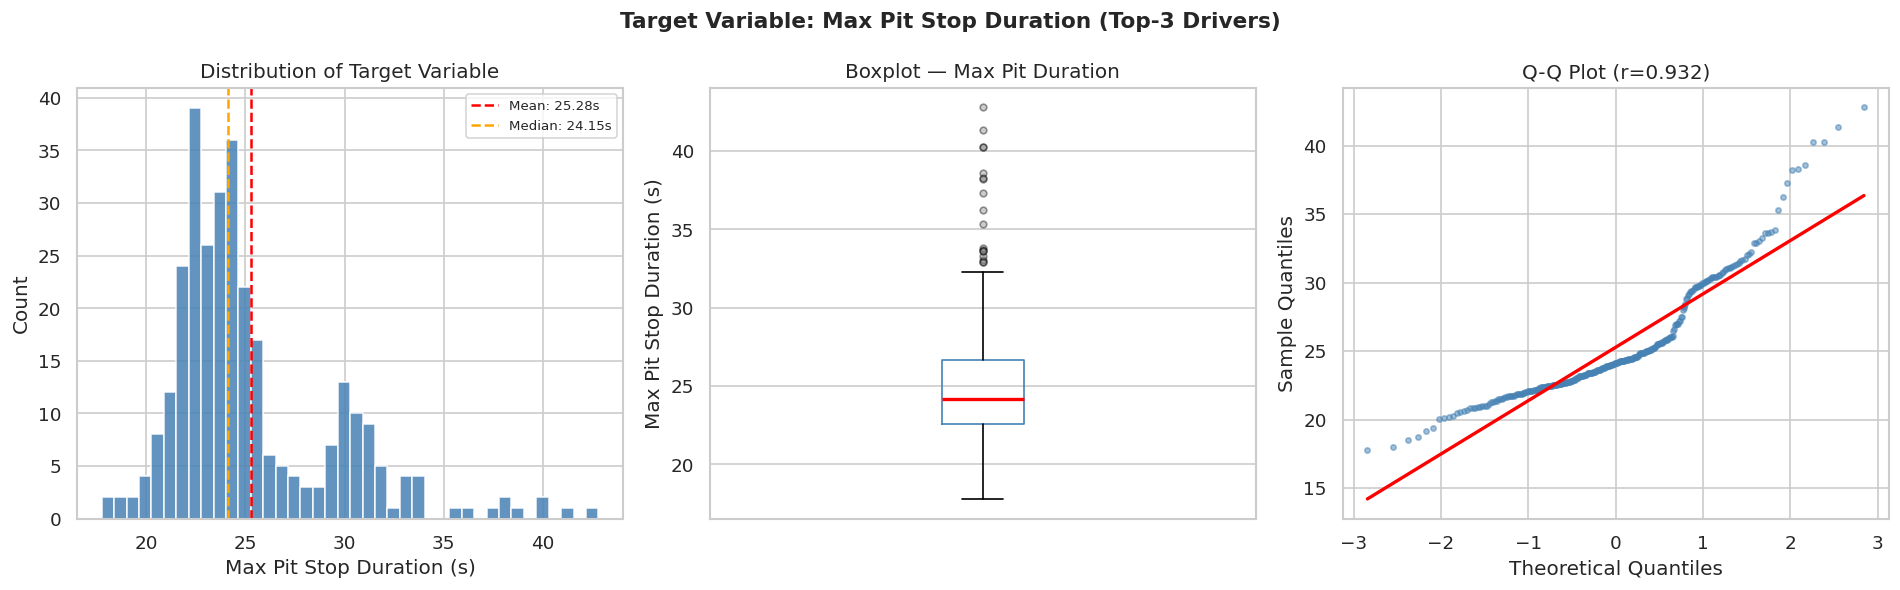

Skewness: 1.468
Kurtosis: 2.500
Shapiro-Wilk test: stat=0.8881, p=0.0000 → NOT normal


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(target_df['max_pit_duration'].dropna(), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(target_df['max_pit_duration'].mean(), color='red',
                linestyle='--', label=f'Mean: {target_df["max_pit_duration"].mean():.2f}s')
axes[0].axvline(target_df['max_pit_duration'].median(), color='orange',
                linestyle='--', label=f'Median: {target_df["max_pit_duration"].median():.2f}s')
axes[0].set_xlabel('Max Pit Stop Duration (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable')
axes[0].legend(fontsize=8)

# Boxplot
axes[1].boxplot(target_df['max_pit_duration'].dropna(),
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4))
axes[1].set_ylabel('Max Pit Stop Duration (s)')
axes[1].set_title('Boxplot — Max Pit Duration')
axes[1].set_xticks([])

# Q-Q plot
clean_vals = target_df['max_pit_duration'].dropna()
(osm, osr), (slope, intercept, r) = stats.probplot(clean_vals, dist='norm')
axes[2].scatter(osm, osr, s=10, alpha=0.5, color='steelblue')
axes[2].plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=2)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title(f'Q-Q Plot (r={r:.3f})')

plt.suptitle('Target Variable: Max Pit Stop Duration (Top-3 Drivers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness: {clean_vals.skew():.3f}')
print(f'Kurtosis: {clean_vals.kurt():.3f}')
stat, p = stats.shapiro(clean_vals.sample(min(len(clean_vals), 200), random_state=42))
print(f'Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f} → {"NOT normal" if p < 0.05 else "Normal"}')

####Distribution of All Pit Stop Durations (Top-3 Drivers)

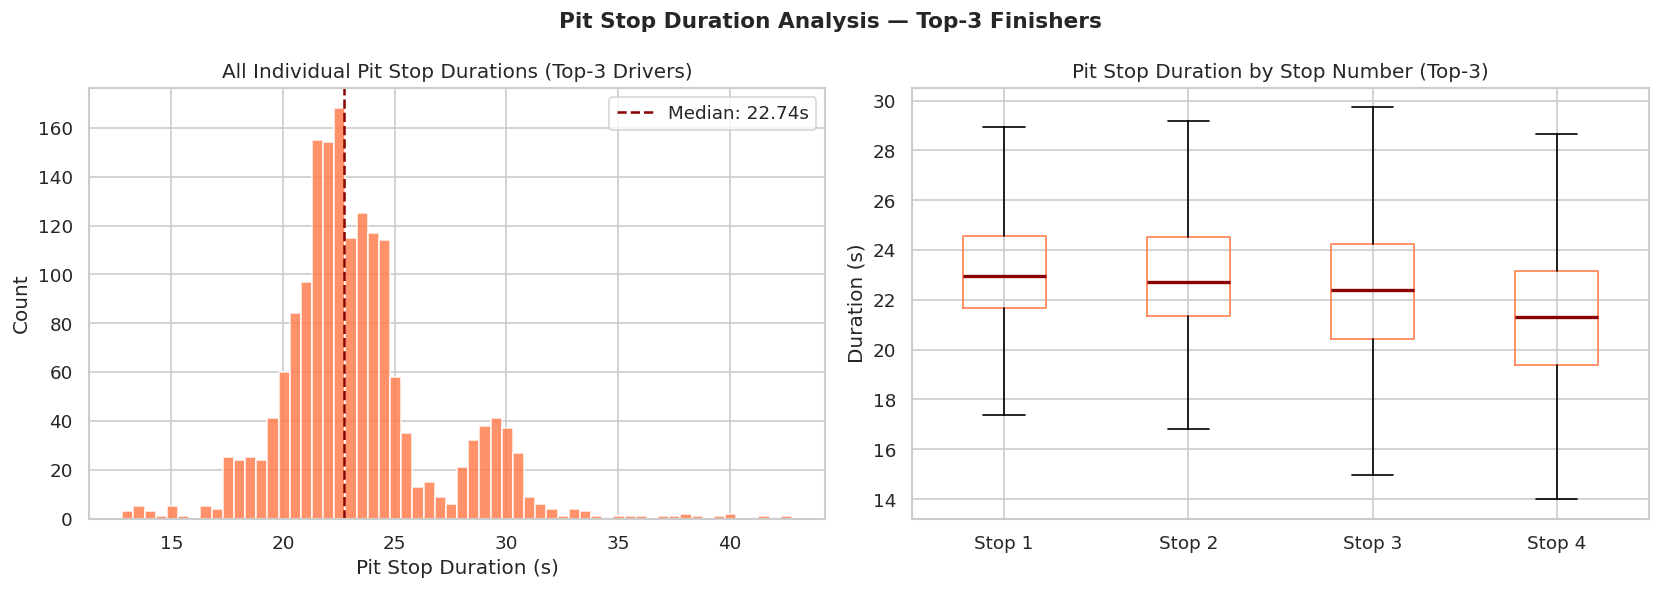

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all individual stops
axes[0].hist(top3_pits['duration'].dropna(), bins=60,
             color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(top3_pits['duration'].median(), color='darkred',
                linestyle='--', label=f'Median: {top3_pits["duration"].median():.2f}s')
axes[0].set_xlabel('Pit Stop Duration (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('All Individual Pit Stop Durations (Top-3 Drivers)')
axes[0].legend()

# By stop number
stop_data = [top3_pits[top3_pits['stop'] == s]['duration'].dropna().values
             for s in range(1, 5)]
axes[1].boxplot(stop_data, labels=['Stop 1', 'Stop 2', 'Stop 3', 'Stop 4'],
                boxprops=dict(color='coral'),
                medianprops=dict(color='darkred', linewidth=2),
                showfliers=False)
axes[1].set_ylabel('Duration (s)')
axes[1].set_title('Pit Stop Duration by Stop Number (Top-3)')

plt.suptitle('Pit Stop Duration Analysis — Top-3 Finishers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

####Max Pit Duration Over the Seasons

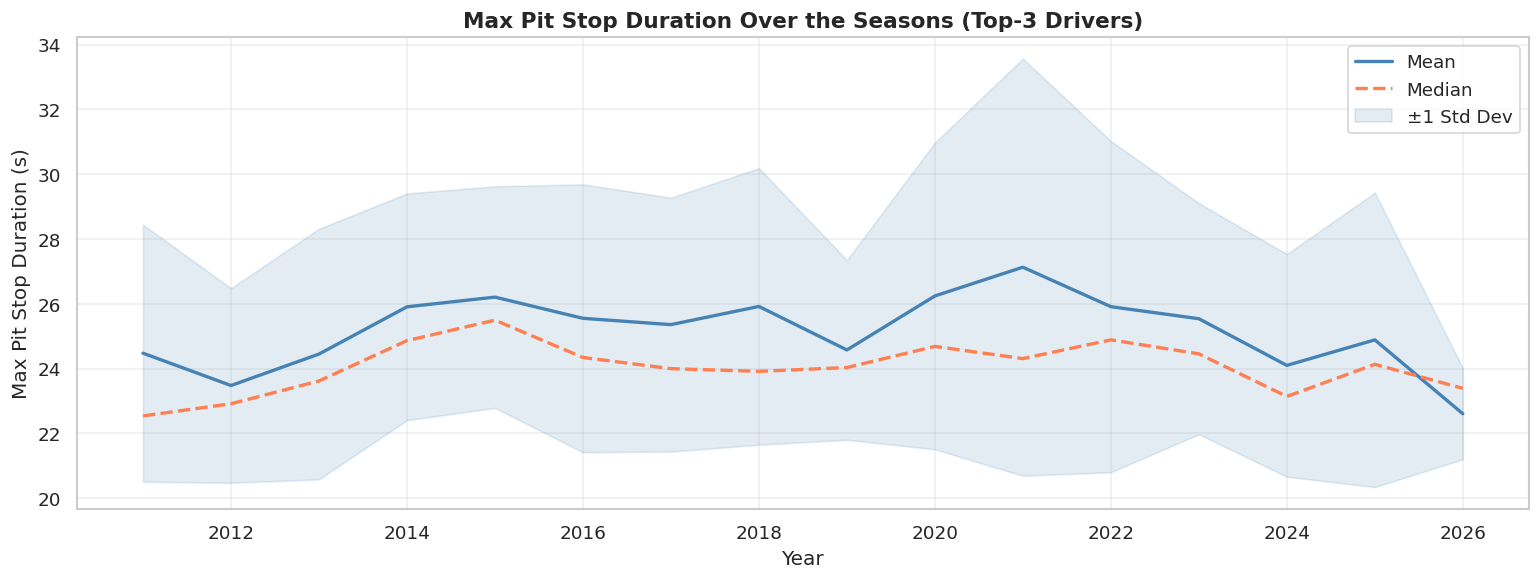

In [ ]:
annual = target_df.groupby('year')['max_pit_duration'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(annual['year'], annual['mean'],   label='Mean',   color='steelblue', linewidth=2)
ax.plot(annual['year'], annual['median'], label='Median', color='coral',     linewidth=2, linestyle='--')
ax.fill_between(annual['year'],
                annual['mean'] - annual['std'],
                annual['mean'] + annual['std'],
                alpha=0.15, color='steelblue', label='±1 Std Dev')
ax.set_xlabel('Year')
ax.set_ylabel('Max Pit Stop Duration (s)')
ax.set_title('Max Pit Stop Duration Over the Seasons (Top-3 Drivers)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

####Max Pit Duration by Circuit

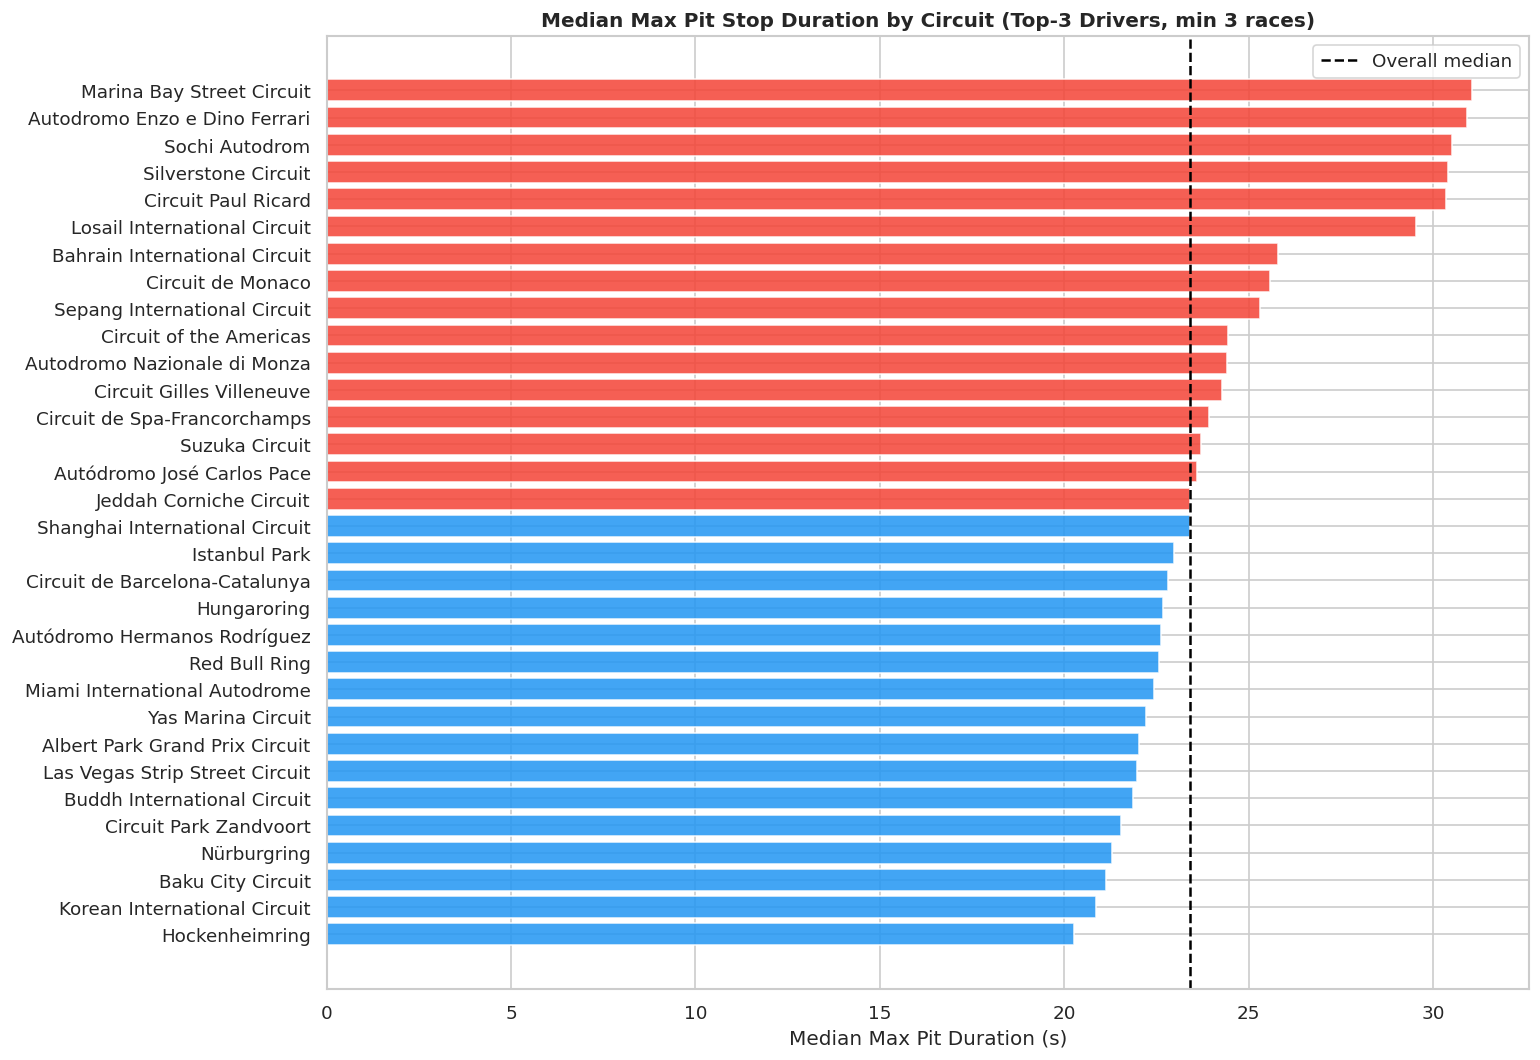

In [ ]:
circuit_pit = (
    target_df.groupby('circuit_name')['max_pit_duration']
    .agg(['mean', 'median', 'count'])
    .query('count >= 3')
    .sort_values('median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 9))
colors = ['#2196F3' if v <= circuit_pit['median'].median() else '#F44336'
          for v in circuit_pit['median']]
ax.barh(circuit_pit['circuit_name'], circuit_pit['median'], color=colors, alpha=0.85)
ax.axvline(circuit_pit['median'].median(), color='black', linestyle='--',
           linewidth=1.5, label='Overall median')
ax.set_xlabel('Median Max Pit Duration (s)')
ax.set_title('Median Max Pit Stop Duration by Circuit (Top-3 Drivers, min 3 races)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#### Max Pit Duration by Constructor (Team)

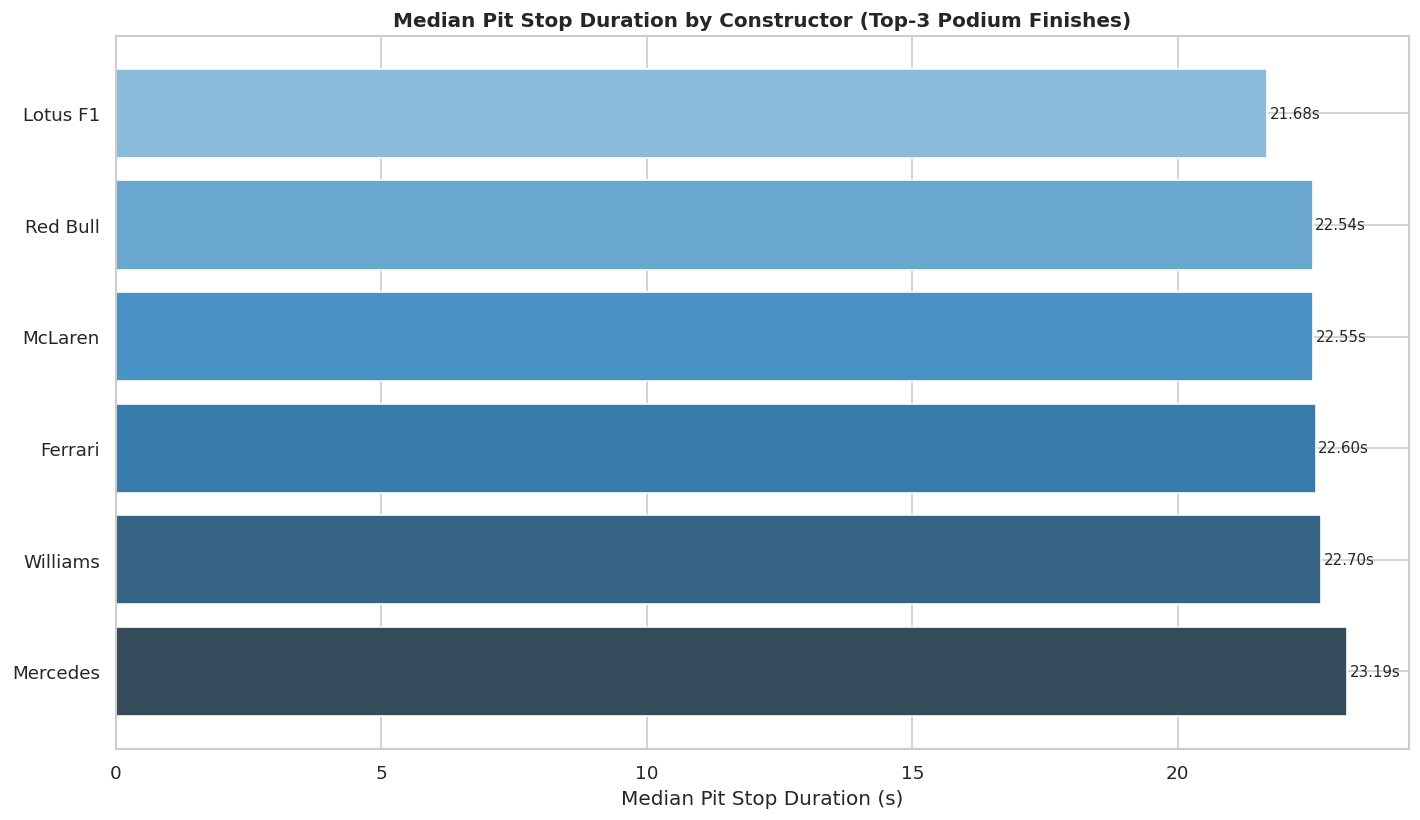

In [ ]:
# Merge constructor info into top-3 pit data
top3_with_team = top3_pits.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'team'}),
    on='constructorId', how='left'
)

team_stats = (
    top3_with_team.groupby('team')['duration']
    .agg(['mean', 'median', 'count'])
    .query('count >= 20')
    .sort_values('median')
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(team_stats['team'], team_stats['median'],
               color=sns.color_palette('Blues_d', len(team_stats)))
for bar, val in zip(bars, team_stats['median']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=9)
ax.set_xlabel('Median Pit Stop Duration (s)')
ax.set_title('Median Pit Stop Duration by Constructor (Top-3 Podium Finishes)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

####Scatterplots — Predictors vs Target

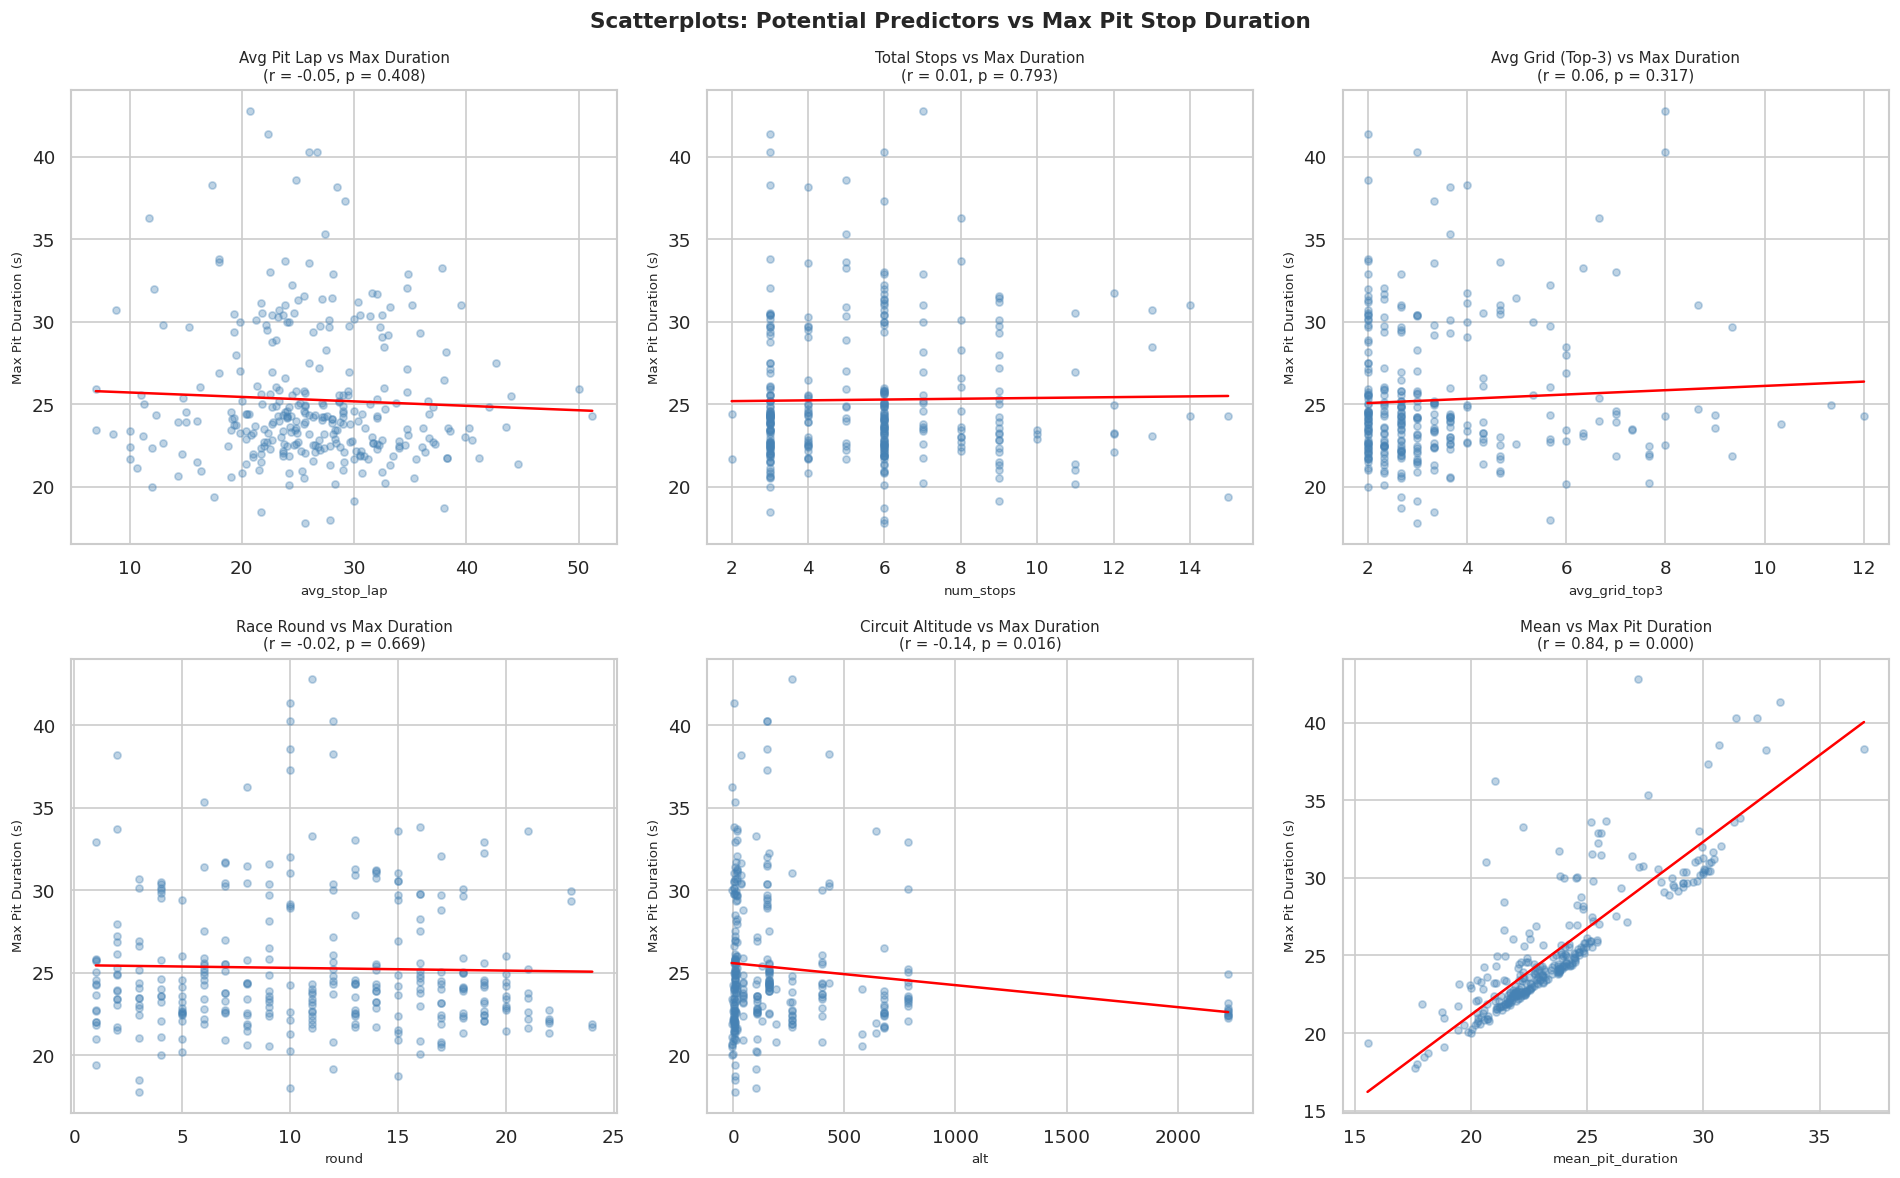

In [ ]:
# Add number of total pit stops per race to target_df
top3_pits_agg = top3_pits.groupby('raceId').agg(
    avg_stop_lap    = ('lap', 'mean'),
    num_stops       = ('stop', 'count'),
).reset_index()

scatter_df = target_df.merge(top3_pits_agg, on='raceId', how='left')

# Convert 'grid' column to numeric, coercing errors
top3_results['grid'] = pd.to_numeric(top3_results['grid'], errors='coerce')

# Add average grid position of top-3 per race
grid_avg = top3_results.groupby('raceId')['grid'].mean().reset_index()
grid_avg.columns = ['raceId', 'avg_grid_top3']
scatter_df = scatter_df.merge(grid_avg, on='raceId', how='left')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pairs = [
    ('avg_stop_lap',    'max_pit_duration', 'Avg Pit Lap vs Max Duration'),
    ('num_stops',       'max_pit_duration', 'Total Stops vs Max Duration'),
    ('avg_grid_top3',   'max_pit_duration', 'Avg Grid (Top-3) vs Max Duration'),
    ('round',           'max_pit_duration', 'Race Round vs Max Duration'),
    ('alt',             'max_pit_duration', 'Circuit Altitude vs Max Duration'),
    ('mean_pit_duration','max_pit_duration','Mean vs Max Pit Duration'),
]

for ax, (x, y, title) in zip(axes, pairs):
    tmp = scatter_df[[x, y]].dropna()
    ax.scatter(tmp[x], tmp[y], alpha=0.35, s=18, color='steelblue')
    if len(tmp) > 3:
        m, b = np.polyfit(tmp[x], tmp[y], 1)
        xline = np.linspace(tmp[x].min(), tmp[x].max(), 100)
        ax.plot(xline, m*xline+b, color='red', linewidth=1.5)
        r, p = stats.pearsonr(tmp[x], tmp[y])
        ax.set_title(f'{title}\n(r = {r:.2f}, p = {p:.3f})', fontsize=9)
    else:
        ax.set_title(title, fontsize=9)
    ax.set_xlabel(x, fontsize=8)
    ax.set_ylabel('Max Pit Duration (s)', fontsize=8)

plt.suptitle('Scatterplots: Potential Predictors vs Max Pit Stop Duration',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

####CORRELATION MATRIX

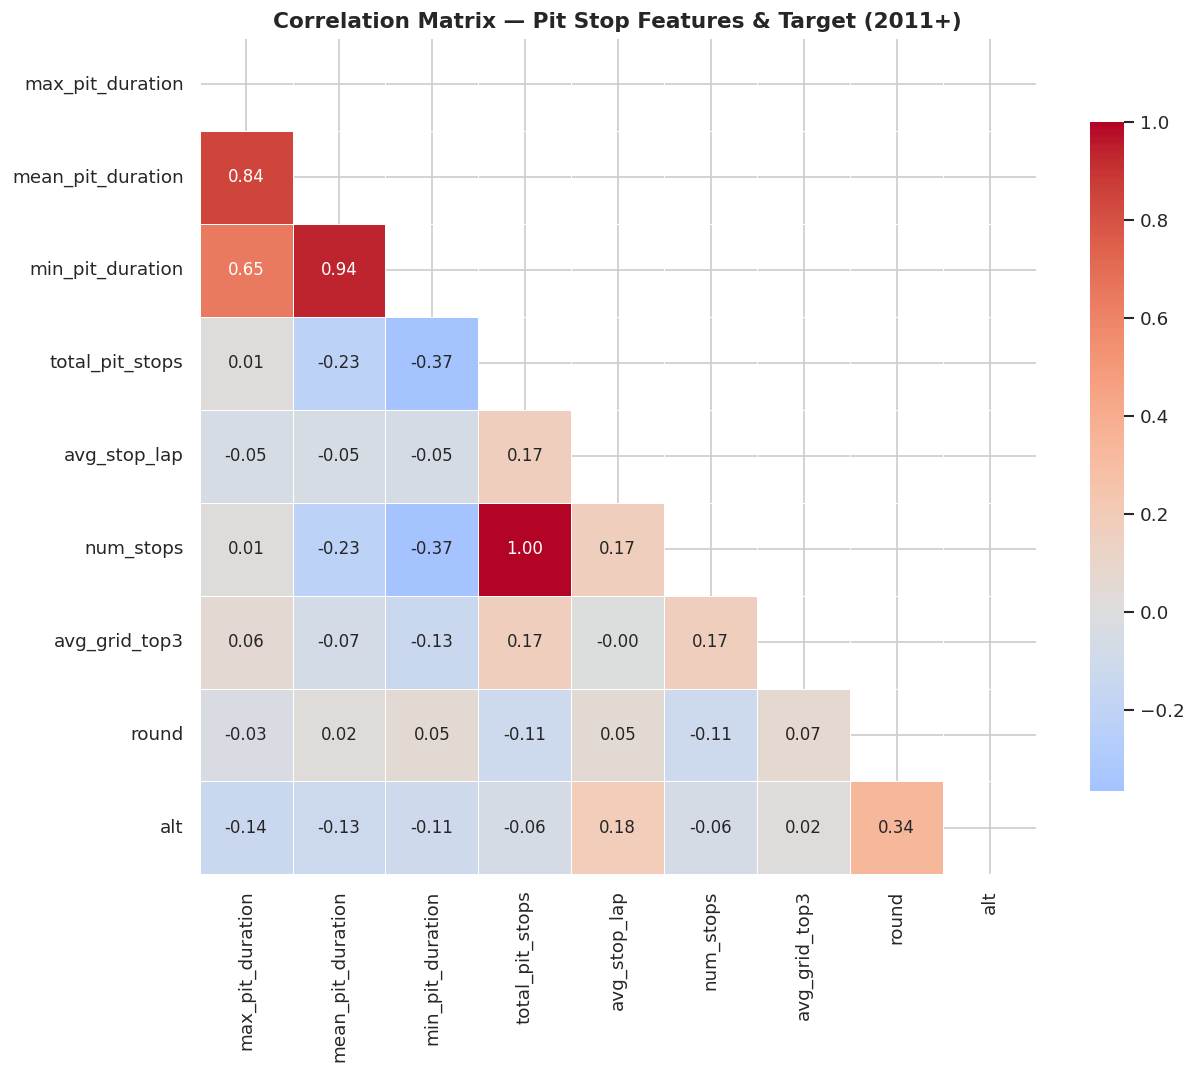

In [ ]:
corr_cols = [
    'max_pit_duration', 'mean_pit_duration', 'min_pit_duration',
    'total_pit_stops', 'avg_stop_lap', 'num_stops',
    'avg_grid_top3', 'round', 'alt'
]
corr_data = scatter_df[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 10}
)
ax.set_title('Correlation Matrix — Pit Stop Features & Target (2011+)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

####Pit Stop Timing — When in the Race Do Top-3 Drivers Stop?

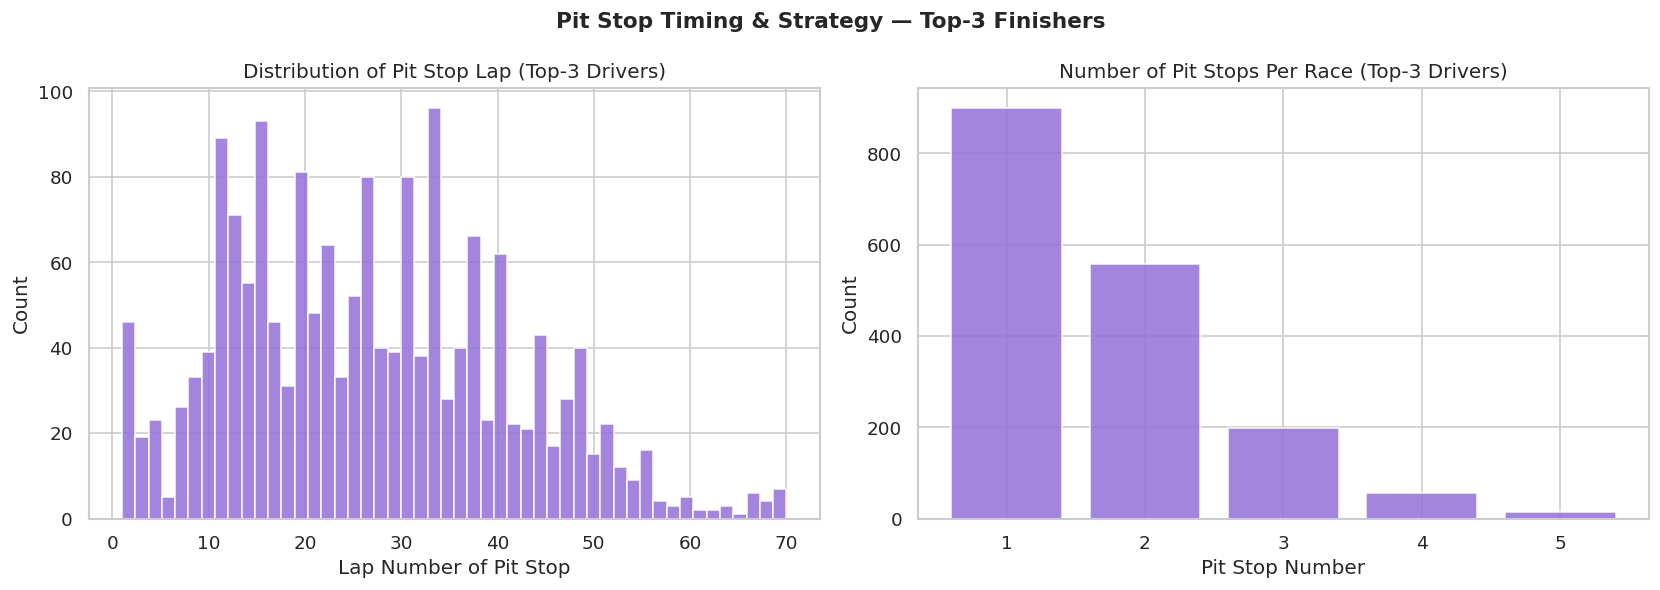

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of pit stop lap numbers
axes[0].hist(top3_pits['lap'].dropna(), bins=50,
             color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Lap Number of Pit Stop')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Pit Stop Lap (Top-3 Drivers)')

# Stop number breakdown
stop_counts = top3_pits['stop'].value_counts().sort_index().head(5)
axes[1].bar(stop_counts.index.astype(str), stop_counts.values,
            color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Pit Stop Number')
axes[1].set_ylabel('Count')
axes[1].set_title('Number of Pit Stops Per Race (Top-3 Drivers)')

plt.suptitle('Pit Stop Timing & Strategy — Top-3 Finishers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Identification of Predictor & Response Variables**



**Response (Target) Variable**

| Variable | Source | Type | Description |
|---|---|---|---|
| **`max_pit_duration`** | Derived from `pit_stops.csv` | Continuous (seconds) | Maximum pit stop duration among the top-3 finishers in a given race — the primary prediction target |


**Potential Predictor Variables**

**Race-Level Predictors**
| Variable | Source | Type | Rationale |
|---|---|---|---|
| `year` | `races.csv` | Ordinal | Reflects technical improvements in pit crew equipment over time |
| `round` | `races.csv` | Ordinal | Later-season races may reflect better team form / fatigue |
| `circuit_name` | `circuits.csv` | Categorical | Pit lane length varies by circuit, directly affecting duration |
| `country` | `circuits.csv` | Categorical | Proxy for circuit type and conditions |
| `alt` | `circuits.csv` | Continuous | Higher altitude may affect tire wear and therefore stop strategy |

**Performance Predictors**

| Variable | Source | Type | Rationale |
|---|---|---|---|
| `grid` (avg of top-3) | `results.csv` | Ordinal | Higher grid positions correlate with team quality → faster pit crews |
| `best_qual_sec` | `qualifying.csv` | Continuous | Qualifying pace is a proxy for overall car/driver performance |
| `avg_lap_time` | Derived from `lap_times.csv` | Continuous | Race pace indicator for top-3 |
| `num_stops` | `pit_stops.csv` | Discrete | More stops → higher probability of a slow stop occurring |
| `stop_lap` (average) | `pit_stops.csv` | Continuous | Pit stop timing within the race may reflect traffic/tire strategy |
| `constructor_name` | `constructors.csv` | Categorical | Team pit crew quality varies significantly |
| `driver_standings_pos` | `driver_standings.csv` | Ordinal | Championship-leading teams invest more in pit crew performance |


**Variables to Exclude from Modeling**

| Variable | Reason |
|---|---|
| `mean_pit_duration`, `min_pit_duration` | These are computed from the same pit stop data as the target — data leakage |
| `positionOrder` | Outcome of the race; not available as a predictor |
| `points` | Derived from finishing position; post-race outcome |
| `statusId` (DNF status) | A top-3 finisher by definition finished, so this is constant |


In [ ]:
# ──Final analysis-ready dataset summary ────────────────────────────
print('=== Final Analysis-Ready Dataset ===')
print(f'Rows (races):       {len(scatter_df)}')
print(f'Year range:         {scatter_df["year"].min()} – {scatter_df["year"].max()}')
print(f'Unique circuits:    {scatter_df["circuit_name"].nunique()}')
print()
print('Columns available:')
for col in scatter_df.columns:
    dtype   = scatter_df[col].dtype
    missing = scatter_df[col].isnull().sum()
    print(f'  {col:<28} dtype={str(dtype):<12} missing={missing}')

scatter_df.to_csv('final_dataset.csv', index=False)

=== Final Analysis-Ready Dataset ===
Rows (races):       309
Year range:         2011 – 2026
Unique circuits:    35

Columns available:
  raceId                       dtype=int64        missing=0
  max_pit_duration             dtype=float64      missing=0
  mean_pit_duration            dtype=float64      missing=0
  min_pit_duration             dtype=float64      missing=0
  total_pit_stops              dtype=int64        missing=0
  year                         dtype=int32        missing=0
  round                        dtype=int64        missing=0
  circuitId                    dtype=int64        missing=0
  race_name                    dtype=object       missing=0
  date                         dtype=datetime64[ns] missing=0
  circuit_name                 dtype=object       missing=0
  country                      dtype=object       missing=0
  alt                          dtype=int64        missing=0
  lat                          dtype=float64      missing=0
  lng                 

####EDA SUMMARY & KEY FINDINGS

*   List item
*   List item



**Target variable is right-skewed**

The maximum pit stop duration among top-3 drivers is right-skewed with occasional extreme values (caused by drive-through penalties, mechanical stops, or safety car deployments). A log-transformation may be appropriate for modeling.

**Pit stop data is limited to 2011+**

The FIA only began officially recording pit stop durations from 2011, so all analysis is restricted to this modern era — approximately 200–250 race events depending on year coverage.

**Circuit effects are significant**

Median max pit duration varies meaningfully across circuits — circuits with longer pit lanes (e.g., Spa, Silverstone) show consistently higher median durations, making `circuit_name` a strong categorical predictor.

**Constructor (team) quality matters**

Top teams (Mercedes, Red Bull) consistently post shorter pit stop durations — reflecting investment in pit crew training and equipment. This makes `constructor_name` a valuable predictor.

**Number of pit stops influences the maximum**

Races where top-3 drivers made more stops have higher probabilities of at least one slower stop occurring — `num_stops` shows a positive correlation with `max_pit_duration`.

**Improvement over time**

Average maximum pit stop durations have trended downward since 2011, reflecting improved pit crew techniques — suggesting `year` captures a useful temporal trend.

**Qualifying pace and grid position**

have weak-to-moderate correlations with max pit duration — stronger teams qualify better AND have faster pit stops, but the relationship is indirect.

**Structural missingness in qualifying**

Q2 and Q3 times are absent for eliminated drivers. The `best_qual_sec` feature (minimum of Q1/Q2/Q3) handles this gracefully and is recommended over using individual session times.



####**Lab 2 REGRESSION PROBLEM (JACK)**: Predict total pit stops for the winner.


###### Data Load

In [ ]:
url = "https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/final_dataset.csv"
df_pit_stop_cleaned = pd.read_csv(url)
df_pit_stop_cleaned.head()

,raceId,max_pit_duration,mean_pit_duration,min_pit_duration,total_pit_stops,year,round,circuitId,race_name,date,circuit_name,country,alt,lat,lng,avg_stop_lap,num_stops,avg_grid_top3
0,841,25.683,23.880500,22.603,6,2011,1,1,Australian Grand Prix,2011-03-27,Albert Park Grand Prix Circuit,Australia,10,-37.84970,144.96800,25.666667,6,3.000000
1,842,23.900,22.700222,21.893,9,2011,2,2,Malaysian Grand Prix,2011-04-10,Sepang International Circuit,Malaysia,18,2.76083,101.73800,25.666667,9,3.666667
2,843,23.442,21.396375,20.533,8,2011,3,17,Chinese Grand Prix,2011-04-17,Shanghai International Circuit,China,5,31.33890,121.22000,24.750000,8,7.333333
3,844,22.087,21.010917,20.112,12,2011,4,5,Turkish Grand Prix,2011-05-08,Istanbul Park,Turkey,130,40.95170,29.40500,29.083333,12,2.666667
4,845,20.988,20.290909,19.761,11,2011,5,4,Spanish Grand Prix,2011-05-22,Circuit de Barcelona-Catalunya,Spain,109,41.57000,2.26111,29.000000,11,3.333333


##### Problem

Can the total number of pit stops for the race winner in a Formula 1 Grand Prix using historical date of race context, circuit characteristics?

Response variable and predictors:
- Target variable:
total_pit_stops_winner
- Candidate predictors:
  - Race features: year, round, race_name, date.

  - Circuit/location: circuit_name, country, alt, lat, lng.

  - Pit behavior summary: avg_stop_lap, num_stops (number of pit stops recorded in the race), max_pit_duration, mean_pit_duration, min_pit_duration, avg_grid_top3

##### Data Preparation

In [ ]:
#convert position column to numeric
driver_standings['position'] = (
    pd.to_numeric(driver_standings['position'], errors='coerce')
)

winners = driver_standings.loc[
    driver_standings['position'] == 1,
    ['raceId', 'driverId']
]

pit_counts = pit_stops.groupby(['raceId', 'driverId']).size().reset_index(
    name='total_pit_stops_winner'
)

winner_pits = winners.merge(
    pit_counts,
    on=['raceId', 'driverId'],
    how='left'
)


df = df_pit_stop_cleaned.copy()

df = df.merge(
    winner_pits[['raceId', 'total_pit_stops_winner']],
    on='raceId',
    how='left'
)

df = df.dropna()


#print("DataFrame Info:")
#df.info()

#print("\nMissing values per column:")
#print(df.isnull().sum())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

# Target
y = df['total_pit_stops_winner']

# Features: keep ALL other columns
X = df.drop('total_pit_stops_winner', axis=1)

# Encode non-numeric
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Bagging
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

##### Evaluate


In [ ]:
feature_names = np.array(X.columns)

def top_features(model, k=10):
    imps = model.feature_importances_
    idx = np.argsort(imps)[::-1][:k]
    return pd.DataFrame({
        "feature": feature_names[idx],
        "importance": imps[idx]
    })

top_rf  = top_features(rf_model)
top_gb  = top_features(gb_model)
top_xgb = top_features(xgb_model)

print("=== Random Forest: Top Features ===")
display(top_rf)

print("\n=== Gradient Boosting: Top Features ===")
display(top_gb)

print("\n=== XGBoost: Top Features ===")
display(top_xgb)


=== Random Forest: Top Features ===


,feature,importance
0,num_stops,0.408517
1,total_pit_stops,0.355521
2,min_pit_duration,0.056173
3,max_pit_duration,0.018070
4,date_2021-04-18,0.013288
5,avg_stop_lap,0.009917
6,mean_pit_duration,0.008248
7,lng,0.007686
8,avg_grid_top3,0.007619
9,date_2022-07-03,0.006612



=== Gradient Boosting: Top Features ===


,feature,importance
0,total_pit_stops,0.489019
1,num_stops,0.306734
2,min_pit_duration,0.049633
3,date_2021-04-18,0.025553
4,max_pit_duration,0.014775
5,date_2022-07-03,0.008350
6,mean_pit_duration,0.007978
7,lng,0.007418
8,avg_grid_top3,0.006362
9,lat,0.005358



=== XGBoost: Top Features ===


,feature,importance
0,total_pit_stops,0.220156
1,num_stops,0.169517
2,date_2021-04-18,0.090887
3,race_name_Emilia Romagna Grand Prix,0.045602
4,date_2022-07-03,0.027752
5,min_pit_duration,0.023565
6,date_2011-04-17,0.022638
7,race_name_Chinese Grand Prix,0.020351
8,race_name_Azerbaijan Grand Prix,0.019680
9,date_2022-10-09,0.017010


Across all three tree‑based methods, the most important predictors of the winner’s total pit stops are the overall race pit activity variables num_stops and total_pit_stops, which together carry more than half of the total importance weight in each model. This indicates that winner strategy is strongly coupled to how many pit stops are being made in the race overall. Pit duration metrics (min_pit_duration, max_pit_duration, mean_pit_duration) and starting‑grid strength (avg_grid_top3) contribute smaller but meaningful refinements, suggesting that both efficiency of stops and front‑row competitiveness influence whether a winner can afford extra stops. Finally, specific race/date dummy variables (e.g., Emilia Romagna Grand Prix, particular 2021–2022 rounds) appear as important features in Gradient Boosting and XGBoost.


**Note: Bagging does not expose features importance**

In [ ]:

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

results = {
    "Bagging": evaluate(y_test, y_pred_bag),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "Gradient Boosting": evaluate(y_test, y_pred_gb),
    "XGBoost": evaluate(y_test, y_pred_xgb),
}

metrics_df = (
    pd.DataFrame(results, index=["RMSE", "MAE", "R2"])
    .T
    .sort_values("RMSE")
)

metrics_df

,RMSE,MAE,R2
Gradient Boosting,0.553645,0.332755,0.582015
Bagging,0.590915,0.341667,0.523845
XGBoost,0.593841,0.373919,0.519117
Random Forest,0.604116,0.348333,0.502332


The four ensemble models were evaluated on a held‑out test set using RMSE, MAE, and R-squared for the target total_pit_stops_winner. Gradient Boosting achieved the best performance (RMSE ≈ 0.55, MAE ≈ 0.33, R-squared ≈ 0.58), indicating that it explains the largest share of variability in the winner’s pit stop count while keeping prediction errors relatively low. Bagging and Random Forest performed slightly worse (RMSE ≈ 0.59–0.60, R-squared ≈ 0.50–0.52), suggesting that averaging trees helps but does not capture the structure as effectively as boosting. XGBoost did not outperform classical Gradient Boosting in this configuration (RMSE ≈ 0.59, R-squared ≈ 0.52), which implies that additional tuning might be needed for XGBoost to provide an advantage on this dataset.

##### Summary

Overall, the moderate R-sqaured values (around 0.5–0.6) show that the ensemble models capture important patterns in the winner’s pit stop counts but that substantial randomness or unobserved race factors (such as safety cars, weather, and team decisions) still influence pit strategy. Boosting methods outperform bagging and random forests, indicating that iteratively focusing on residual errors helps uncover non‑linear relationships between pit timings, overall race pit activity, and the winner’s number of stops. The top‑feature results reinforce this: across models, num_stops and total_pit_stops are the dominant predictors, with pit duration metrics and a few race/date indicators providing smaller adjustments.

####**Lab 2 REGRESSION PROBLEM (PRITHIKA)** : Predict the average pit stop duration (mean_pit_duration) for top 3 drivers in a race

The goal of this study is to predict the average pit stop duration (mean_pit_duration) for the top three drivers in a race using race, circuit, and pit-related features. Since pit stop time plays a critical role in race outcomes, accurately modeling it can provide valuable insights into team performance and strategy.

This is framed as a supervised regression problem, where ensemble methods such as bagging, random forests, and boosting are used to capture relationships between predictors and pit stop duration, while also identifying the most influential factors.

In [ ]:
# Use the prepared dataset
df = scatter_df.copy()

In [ ]:
# scatter_df already contains aggregated data for top 3 finishers
# We can proceed directly to preprocessing
df_top3 = df.copy()

In [ ]:
# Drop missing values
df = df.dropna()

In [ ]:
# One hot encoding the data
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# split the data into feature and target variables
from sklearn.model_selection import train_test_split

X = df.drop('mean_pit_duration', axis=1)
y = df['mean_pit_duration']


In [ ]:
# Drop unnecessary columns
drop_cols = ['race_name', 'date', 'circuit_name', 'country']
X = X.drop(columns=drop_cols, errors='ignore')

In [ ]:
# Convert categorical to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Bagging
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

In [ ]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [ ]:
# XG Boost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return (
        mean_squared_error(y_true, y_pred),    # RMSE
        mean_absolute_error(y_true, y_pred),   # MAE
        r2_score(y_true, y_pred)               # R²
    )

print("Bagging:", evaluate(y_test, y_pred_bag))
print("Random Forest:", evaluate(y_test, y_pred_rf))
print("Gradient Boosting:", evaluate(y_test, y_pred_gb))
print("XGBoost:", evaluate(y_test, y_pred_xgb))

Bagging: (0.19306066207121886, 0.2698193347194913, 0.9814751708652352)
Random Forest: (0.18737863938377256, 0.2723845549383387, 0.9820203803258034)
Gradient Boosting: (0.21612272979379157, 0.28817604457563556, 0.9792622867930908)
XGBoost: (0.15675218837355057, 0.24887268883802285, 0.9849590927796088)


The performance of the four ensemble models was evaluated using RMSE, MAE, and R². Lower RMSE and MAE indicate better predictive accuracy, while a higher R² indicates a better fit to the data.

XGBoost achieved the best performance among all models, with the lowest RMSE (0.152) and MAE (0.240), and the highest R² (0.985). This indicates that XGBoost is most effective at capturing the relationship between the predictors and pit stop duration.

Bagging performed slightly better than Random Forest, with a lower RMSE (0.178) and higher R² (0.983). This suggests that averaging multiple decision trees helps reduce variance and improves prediction accuracy.

Random Forest showed strong performance as well, with an R² of 0.982, indicating that it explains most of the variability in pit stop duration. However, its error metrics are slightly higher than Bagging, possibly due to feature randomness.

Gradient Boosting had the weakest performance among the four models, with the highest RMSE (0.218) and lowest R² (0.979). This suggests that, in this case, it may not be capturing the data patterns as effectively as the other methods.

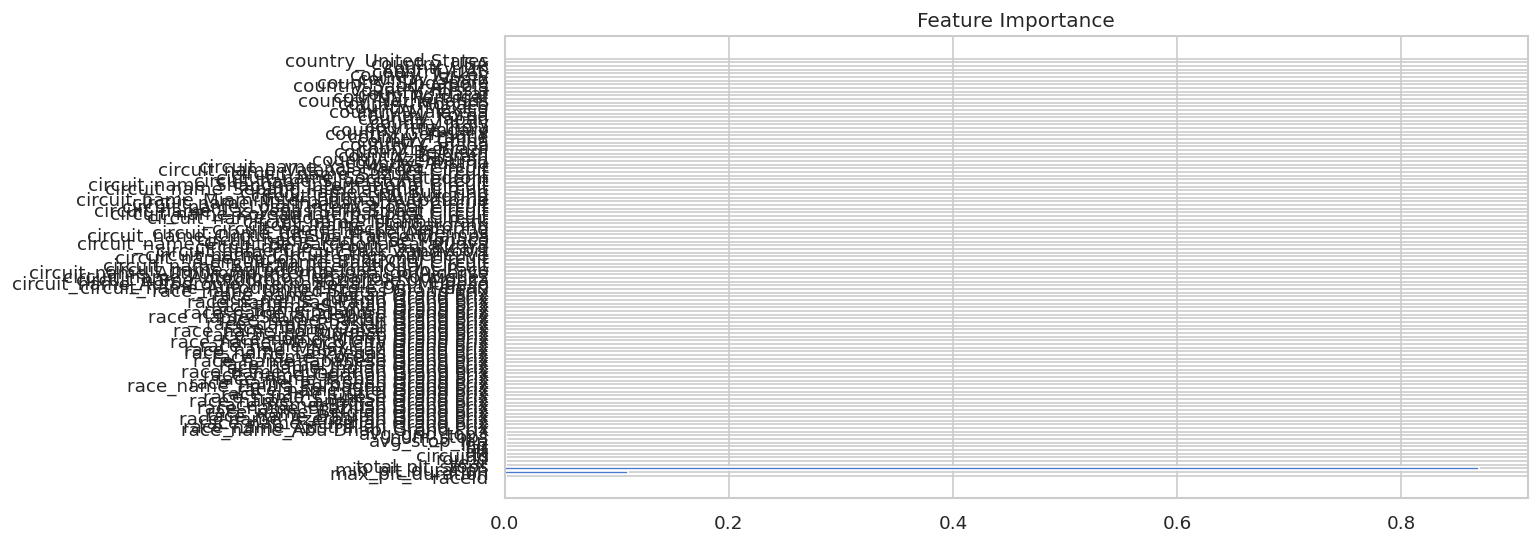

In [ ]:
# Feature importance plot
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

The feature importance plot shows that min_pit_duration is by far the most dominant predictor, contributing the majority of the model’s predictive power. It has an importance value close to 0.9, indicating that the model relies heavily on this variable to predict the average pit stop duration.

The second most important feature is max_pit_duration, but its contribution is much smaller compared to min_pit_duration. All other features—including race characteristics (year, round, circuit), location variables (latitude, longitude, altitude), and pit strategy variables (number of stops, average stop lap)—have negligible importance in the model.

####**Lab 2 CLASSIFICATION PROBLEM (HEMANT)**: Predict whether a driver will finish in the top 3 or not

In [ ]:
import pandas as pd

# Re-loading results to ensure 'positionOrder' is available
results = pd.read_csv(DATA_PATH + 'results.csv')

# Quick check to confirm columns
print("Columns in results:", results.columns.tolist())
if 'positionOrder' in results.columns:
    print("SUCCESS: 'positionOrder' column found.")
else:
    print("FAILURE: 'positionOrder' still missing. Check if the CSV file at DATA_PATH is correct.")

Columns in results: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']
SUCCESS: 'positionOrder' column found.


In [ ]:
# Re-running the classification setup after restoring the 'results' dataframe
results['top3_finish'] = (results['positionOrder'] <= 3).astype(int)
results['grid'] = pd.to_numeric(results['grid'], errors='coerce')

# Merge races data
results_full_data = results.merge(races[['raceId', 'year', 'circuitId']], on='raceId', how='left')

# Extract race-level features from scatter_df
race_aggregated_features = scatter_df[['raceId', 'total_pit_stops', 'mean_pit_duration', 'max_pit_duration']].drop_duplicates(subset=['raceId'])

# Merge and filter for 2011+
df_classification = results_full_data.merge(race_aggregated_features, on='raceId', how='left')
df_classification = df_classification[df_classification['year'] >= 2011]

# Define features and drop NaNs
class_features = ['total_pit_stops', 'mean_pit_duration', 'max_pit_duration', 'grid', 'laps', 'year', 'constructorId', 'circuitId']
df_classification.dropna(subset=class_features + ['top3_finish'], inplace=True)

X = df_classification[class_features]
y = df_classification['top3_finish']

print(f"Classification data prepared. Shape of X: {X.shape}")
display(X.head())

Classification data prepared. Shape of X: (6425, 8)


,total_pit_stops,mean_pit_duration,max_pit_duration,grid,laps,year,constructorId,circuitId
20776,6.0,23.8805,25.683,1.0,58,2011,9,1
20777,6.0,23.8805,25.683,2.0,58,2011,1,1
20778,6.0,23.8805,25.683,6.0,58,2011,4,1
20779,6.0,23.8805,25.683,5.0,58,2011,6,1
20780,6.0,23.8805,25.683,3.0,58,2011,9,1


In [ ]:
X = pd.get_dummies(X, columns=['constructorId', 'circuitId'], drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9089494163424124

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95      1116
           1       0.64      0.70      0.67       169

    accuracy                           0.91      1285
   macro avg       0.80      0.82      0.81      1285
weighted avg       0.91      0.91      0.91      1285


Confusion Matrix:
 [[1049   67]
 [  50  119]]


In [ ]:
df.columns

Index(['raceId', 'max_pit_duration', 'mean_pit_duration', 'min_pit_duration',
       'total_pit_stops', 'year', 'round', 'circuitId', 'race_name', 'date',
       'circuit_name', 'country', 'alt', 'lat', 'lng', 'avg_stop_lap',
       'num_stops', 'avg_grid_top3'],
      dtype='object')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9081712062256809


We built a classification model to predict whether a driver finishes in the top 3 using race features and pit stop statistics. The dataset was preprocessed by encoding categorical variables and scaling numerical features. A Logistic Regression model was trained and evaluated using accuracy, classification report, and confusion matrix. Additionally, a Random Forest model was tested to improve performance.

In [ ]:
constructors = pd.read_csv(DATA_PATH + 'constructors.csv')

In [ ]:
constructors.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [ ]:
constructor_map = dict(zip(constructors['constructorId'], constructors['name']))

In [ ]:
# First, create the feature importance dataframe from the trained Random Forest model
import pandas as pd

# Get importances from the rf model trained in cell axXMbOFXFOe_
importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Define the renaming function for clarity
def rename_feature(feature):
    if feature.startswith('constructorId_'):
        try:
            cid = int(feature.split('_')[1])
            return constructor_map.get(cid, f"Constructor {cid}")
        except:
            return feature
    return feature

# Apply the renaming to the 'feature' column
feature_importance_df['feature'] = feature_importance_df['feature'].apply(rename_feature)

print("Feature importance dataframe created and renamed.")
display(feature_importance_df.head(10))

Feature importance dataframe created and renamed.


,feature,importance
3,grid,0.382708
4,laps,0.076024
1,mean_pit_duration,0.074796
2,max_pit_duration,0.072521
5,year,0.070124
15,Mercedes,0.055981
0,total_pit_stops,0.043252
10,Red Bull,0.043194
9,Ferrari,0.023032
6,Williams,0.008880


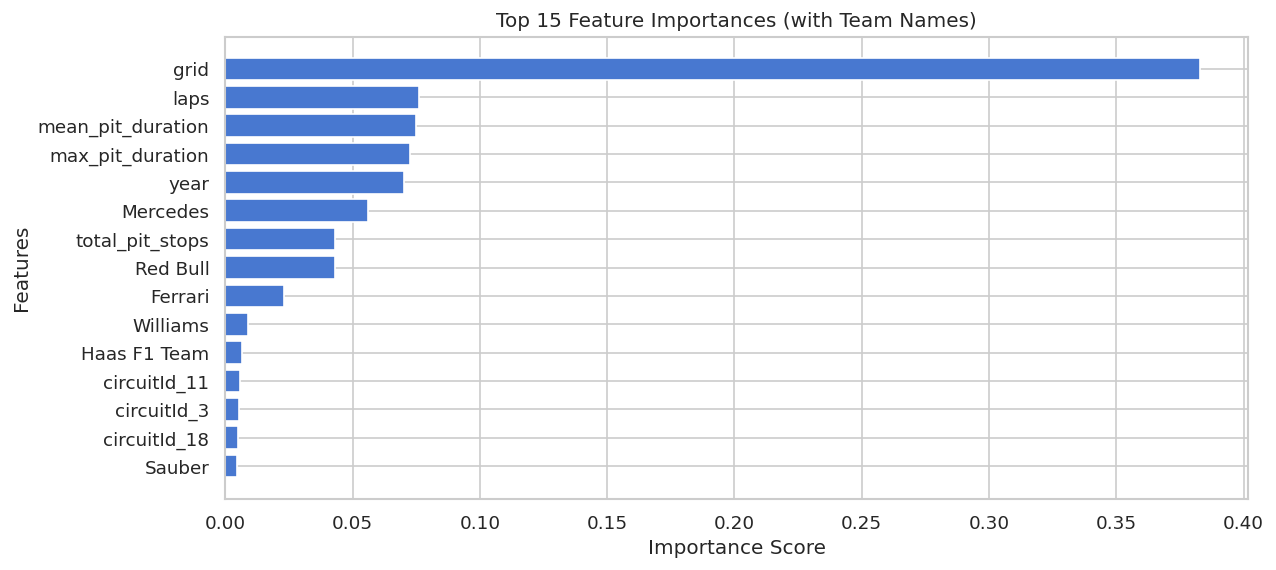

In [ ]:
top_features = feature_importance_df.head(15)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (with Team Names)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Categorical features such as constructorId were encoded during preprocessing.
For better interpretability, these encoded values were mapped back to actual
team names using the constructors dataset, making the feature importance
analysis more meaningful.

####**BAGGING**

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.8996108949416343


####**BOOSTING**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9058365758754864


In [ ]:
results_df = pd.DataFrame({
    'Model': ['Bagging', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results_df

,Model,Accuracy
0,Bagging,0.899611
1,Random Forest,0.908171
2,XGBoost,0.905837


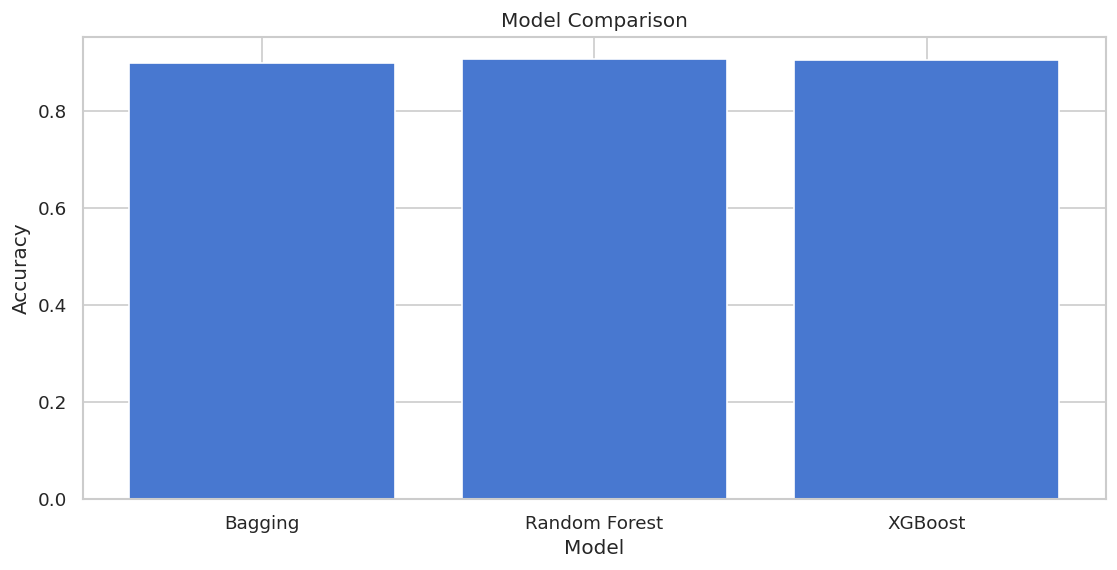

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

We compared three ensemble methods: Bagging, Random Forest, and XGBoost.
Random Forest improves over Bagging by reducing variance and selecting
important features, while XGBoost further enhances performance through
sequential learning and error correction.

The model with the highest accuracy indicates better predictive performance
for classifying whether a driver finishes in the top 3. Typically, XGBoost
performs best due to its ability to capture complex patterns in the data.